# 04. 6xSR Examples Downstream Segmentation with SynthSeg

This notebook covers:

1. Visualizing 6x SR results on example cases.
2. Applying SynthSeg as a fixed brain MRI segmentation model.
3. Comparing LR/SR segmentations with the Neurite-OASIS ground-truth labels.

The idea is simple: if SR restores anatomically meaningful structures, SynthSeg should produce segmentations closer to the HR ground truth.

## 1. Visualize 6x SR examples

The test script saves 3D inference results under `results/`. You can visualize your own outputs using the same approach as in Section 6 of `03_evaluation.ipynb`.

For convenience, this notebook also includes several precomputed examples under `examples/`.


In [1]:
from pathlib import Path
from utils import visualize_examples_sr, visualize_examples_sr_with_seg, compute_examples_seg_dice_table

project_root = Path.cwd().resolve()
if project_root.name == "tutorial":
    project_root = project_root.parent

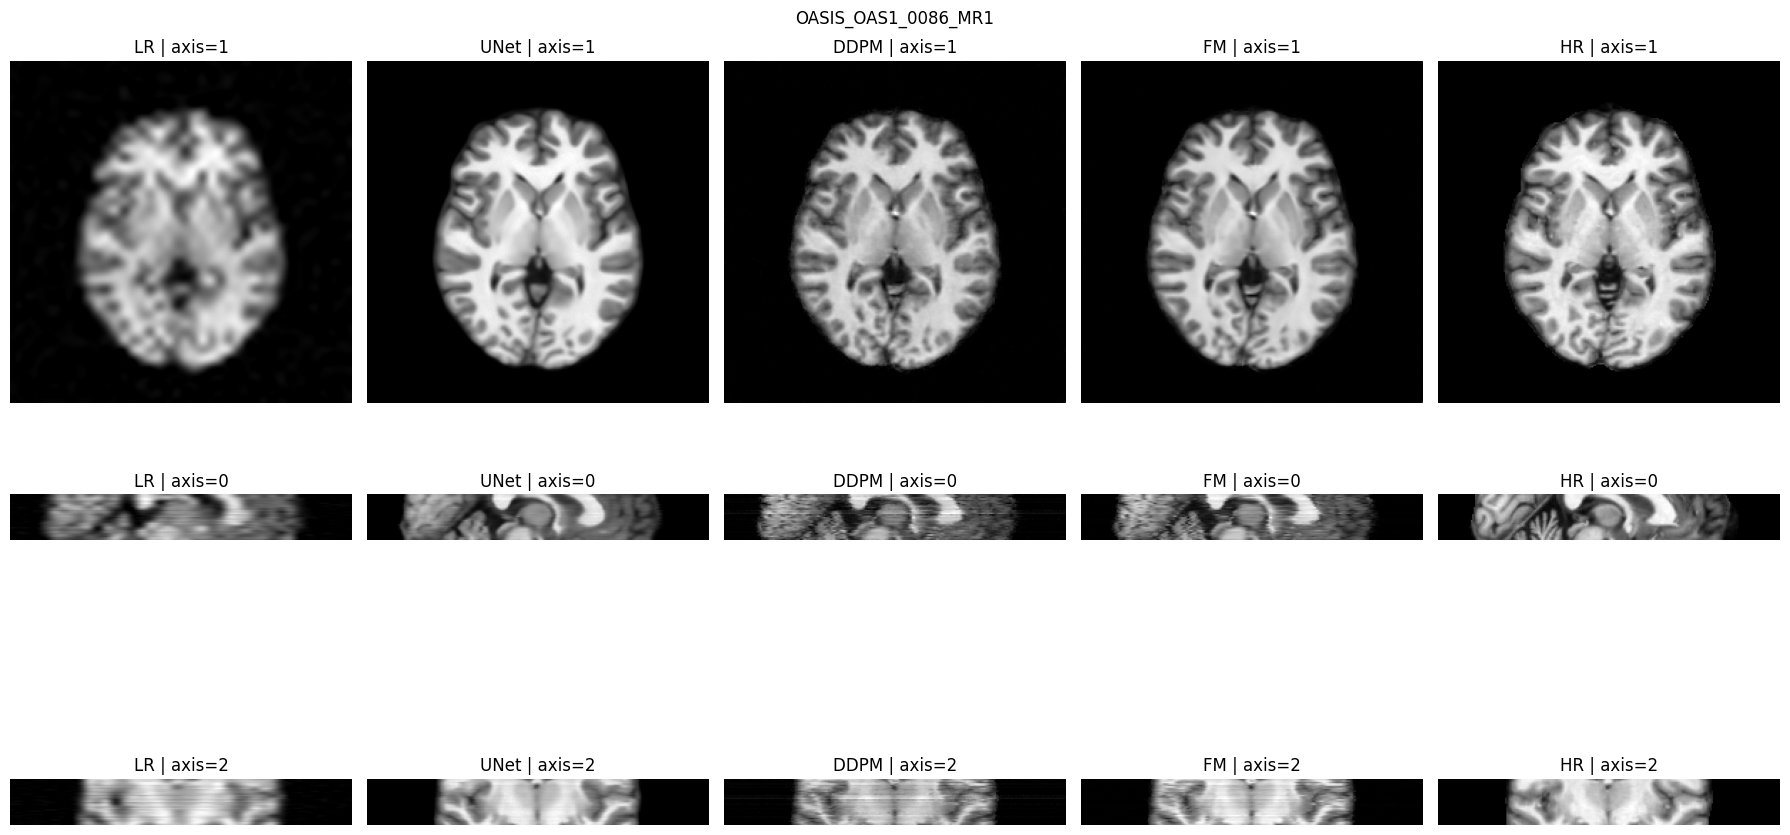

In [2]:
examples_root = project_root / "examples"
lr_dir = examples_root / "LR"
hr_dir = examples_root / "HR"
unet_sr_dir = examples_root / "unet_2p5d"
ddpm_sr_dir = examples_root / "ddpm_2p5d"
fm_sr_dir = examples_root / "fm_2p5d"

visualize_examples_sr(
    lr_dir=lr_dir,
    hr_dir=hr_dir,
    unet_sr_dir=unet_sr_dir,
    ddpm_sr_dir=ddpm_sr_dir,
    fm_sr_dir=fm_sr_dir,
    max_cases=1,
)

## 2. Downstream validation with SynthSeg

PSNR and SSIM measure image-level similarity, but they do not directly show whether SR improves downstream medical image analysis. Here, we use [SynthSeg](https://github.com/BBillot/SynthSeg) as a fixed downstream segmentation model.

SynthSeg is a contrast-agnostic brain MRI segmentation method. Since it can handle different MRI contrasts and resolutions without retraining, it is suitable for comparing LR and SR images under the same segmentation pipeline.

In this notebook, we evaluate downstream segmentation as follows:

- Run SynthSeg on LR and SR images.
- Use the Neurite-OASIS segmentation labels as ground truth.
- Compute Dice scores between SynthSeg outputs and the ground truth labels.

This tests whether SR makes the image more useful for anatomical segmentation.


## 3. Install SynthSeg and run segmentation

Install SynthSeg in a **separate environment**, because it depends on TensorFlow/Keras and may conflict with the PyTorch SR environment.

Official installation guide: https://github.com/BBillot/SynthSeg#installation

Run SynthSeg from the SynthSeg repository:

```bash
python ./scripts/commands/SynthSeg_predict.py --i <your_LR_or_SR_folder> --o <your_output_seg_folder> --v1 --fast
```

Add `--cpu` if GPU setup causes compatibility issues:

In this notebook, we provide precomputed SynthSeg outputs for the example cases. We also map SynthSeg labels to the Neurite-OASIS label space before computing Dice.


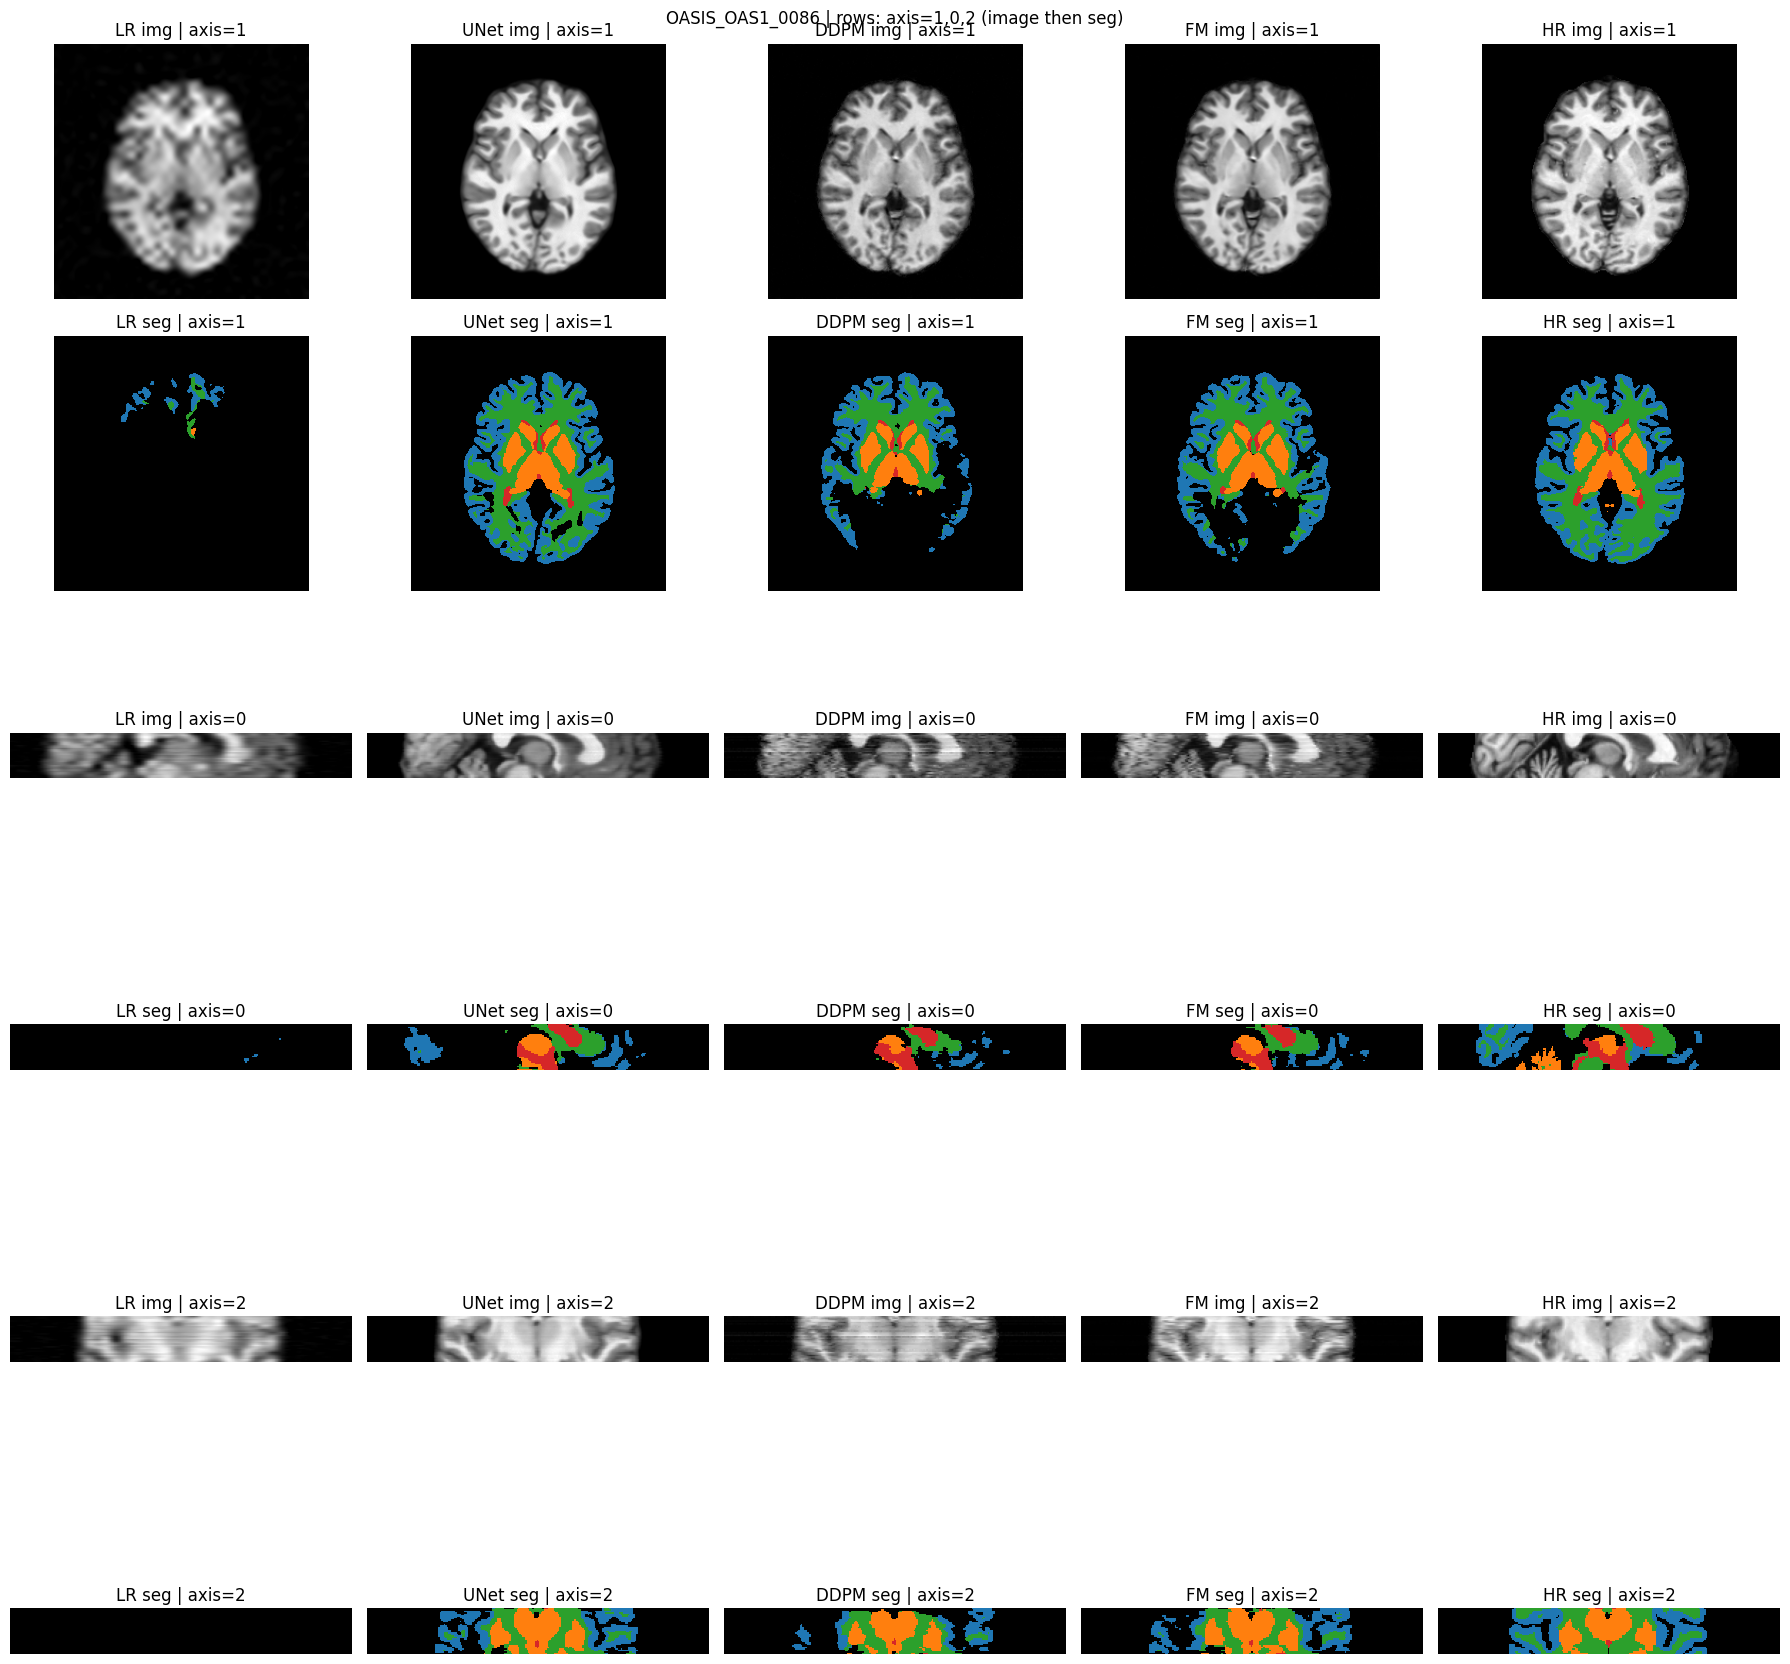

In [3]:
# Segmentation folders are stored as "seg/" under each image directory.
# SynthSeg outputs are mapped to the Neurite-OASIS label space in utils.py.
visualize_examples_sr_with_seg(
    lr_dir=lr_dir,
    hr_dir=hr_dir,
    unet_sr_dir=unet_sr_dir,
    ddpm_sr_dir=ddpm_sr_dir,
    fm_sr_dir=fm_sr_dir,
    max_cases=1,
)

## 4. Compute Dice scores

We compare the segmentation results against the Neurite-OASIS ground-truth labels:

- `SynthSeg(LR)` vs. ground truth.
- `SynthSeg(SR)` vs. ground truth.

Background label `0` is ignored. The code reports per-case Dice scores and a summary table for LR, UNet, DDPM, and Flow Matching.


In [4]:
case_df, summary_df = compute_examples_seg_dice_table(
    lr_dir=lr_dir,
    hr_dir=hr_dir,
    unet_sr_dir=unet_sr_dir,
    ddpm_sr_dir=ddpm_sr_dir,
    fm_sr_dir=fm_sr_dir,
)

# print("Per-case Dice (each sample):")
# display(case_df.round(4))

print("\nSummary Dice table (rows=LR/UNet/DDPM/FM):")
display(summary_df.round(4))


Summary Dice table (rows=LR/UNet/DDPM/FM):


,Cortex,SubcorticalGM,WhiteMatter,CSF_Ventricles,MeanDice
model,,,,,
LR,0.0546,0.0016,0.0203,0.0002,0.0192
UNet,0.6867,0.7848,0.7213,0.7713,0.7411
DDPM,0.4653,0.7326,0.4964,0.5456,0.5600
FM,0.5787,0.7753,0.6075,0.6705,0.6580
